## 6.2 PyTorchでDDQNをxArm6でやる

In [2]:
# パッケージのimport
import numpy as np
import matplotlib.pyplot as plt
import pyrealsense2 as rs
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import time, os
from xarm.wrapper import XArmAPI
import sounddevice as sd
import torch
import pygame

SDK_VERSION: 1.15.3
pygame 2.6.1 (SDL 2.28.4, Python 3.12.7)
Hello from the pygame community. https://www.pygame.org/contribute.html


c:\Users\KentaYonekura\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
# 動画の描画関数の宣言
# 参考URL http://nbviewer.jupyter.org/github/patrickmineault
# /xcorr-notebooks/blob/master/Render%20OpenAI%20gym%20as%20GIF.ipynb
from JSAnimation.IPython_display import display_animation
from matplotlib import animation
from IPython.display import display


def display_frames_as_gif(frames):
    """
    Displays a list of frames as a gif, with controls
    """
    plt.figure(figsize=(frames[0].shape[1] / 72.0, frames[0].shape[0] / 72.0),
               dpi=72)
    patch = plt.imshow(frames[0])
    plt.axis('off')

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(plt.gcf(), animate, frames=len(frames),
                                   interval=50)

    anim.save('movie_cartpole_DDQN.mp4')  # 動画のファイル名と保存です
    display(display_animation(anim, default_mode='loop'))


In [4]:
# 効果音用
class SoundManager:
    def __init__(self):
        pygame.mixer.init(frequency=44100, size=-16, channels=2, buffer=512)
        self.sounds = {}
        self.loaded = False
    
    def load_sounds(self):
        """効果音を事前にロード"""
        sound_files = {
            'pon': './pon.mp3',
            'pafu': './pafu.mp3', 
            'levelup': './levelup.mp3',
        }
        
        for name, filepath in sound_files.items():
            if os.path.exists(filepath):
                try:
                    self.sounds[name] = pygame.mixer.Sound(filepath)
                    print(f"効果音ロード成功: {name}")
                except pygame.error as e:
                    print(f"効果音ロード失敗 {name}: {e}")
            else:
                print(f"ファイルが見つかりません: {filepath}")
        
        self.loaded = True
    
    def play(self, sound_name, volume=1.0):
        """効果音を再生（即座に再生、ブロックしない）"""
        if not self.loaded:
            self.load_sounds()
        
        if sound_name in self.sounds:
            sound = self.sounds[sound_name]
            sound.set_volume(volume)
            sound.play()
        else:
            print(f"効果音が見つかりません: {sound_name}")
    
    def stop_all(self):
        """すべての効果音を停止"""
        pygame.mixer.stop()

# グローバルなサウンドマネージャーを作成
sound_manager = SoundManager()

In [5]:
# namedtupleを生成
from collections import namedtuple

Transition = namedtuple(
    'Transition', ('state', 'action', 'next_state', 'reward'))


In [6]:
# 定数の設定
GAMMA = 0.99  # 時間割引率
MAX_STEPS = 200  # 1試行のstep数
NUM_EPISODES = 1500  # 最大試行回数

# ロボットの定数の設定
MAX_TCP_SPEED = 1000  # mm/s
MIN_CART_POS = -0.22
MAX_CART_POS = 0.22
MAX_CART_VEL = MAX_TCP_SPEED / 1000.
MAX_POLE_ANGLE = 0.87   # 約50度
MAX_POLE_VEL = 2.
MOVE_CART_STEP = 100  # [mm]

In [7]:
# 経験を保存するメモリクラスを定義します


class ReplayMemory:

    def __init__(self, CAPACITY):
        self.capacity = CAPACITY  # メモリの最大長さ
        self.memory = []  # 経験を保存する変数
        self.index = 0  # 保存するindexを示す変数

    def push(self, state, action, state_next, reward):
        '''transition = (state, action, state_next, reward)をメモリに保存する'''

        if len(self.memory) < self.capacity:
            self.memory.append(None)  # メモリが満タンでないときは足す

        # namedtupleのTransitionを使用し、値とフィールド名をペアにして保存します
        self.memory[self.index] = Transition(state, action, state_next, reward)

        self.index = (self.index + 1) % self.capacity  # 保存するindexを1つずらす

    def sample(self, batch_size):
        '''batch_size分だけ、ランダムに保存内容を取り出す'''
        return random.sample(self.memory, batch_size)

    def __len__(self):
        '''関数lenに対して、現在の変数memoryの長さを返す'''
        return len(self.memory)


In [8]:
# ディープ・ニューラルネットワークの構築
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self, n_in, n_mid, n_out):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(n_in, n_mid)
        self.fc2 = nn.Linear(n_mid, n_mid)
        self.fc3 = nn.Linear(n_mid, n_out)

    def forward(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        output = self.fc3(h2)
        return output


In [9]:
# エージェントが持つ脳となるクラスです、DDQNを実行します

import random
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
import pickle, json
from datetime import datetime

BATCH_SIZE = 32
CAPACITY = 10000


class Brain:
    def __init__(self, num_states, num_actions):
        self.num_states = num_states  # CartPoleの状態（位置、速度、角度、角速度）の4を取得
        self.num_actions = num_actions  # CartPoleの行動（右に左に押す）の2を取得

        # 経験を記憶するメモリオブジェクトを生成
        self.memory = ReplayMemory(CAPACITY)

        # ニューラルネットワークを構築
        n_in, n_mid, n_out = num_states, 32, num_actions
        self.main_q_network = Net(n_in, n_mid, n_out)  # Netクラスを使用
        self.target_q_network = Net(n_in, n_mid, n_out)  # Netクラスを使用
        print(self.main_q_network)  # ネットワークの形を出力

        # 最適化手法の設定
        self.optimizer = optim.Adam(
            self.main_q_network.parameters(), lr=0.0001)
        
        # 学習状態管理
        self.episode_count = 0
        self.total_steps = 0
        self.training_history = []

        # 保存ディレクトリの設定
        self.save_dir = "./saved_models"
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    def save_model(self, episode=None, additional_info=None):
        """
        学習済みモデルと状態を保存
        Args:
            episode: 現在のエピソード数
            additional_info: 追加の保存情報（辞書形式）
        """
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        if episode is not None:
            filename_base = f"ddqn_model_ep{episode}_{timestamp}"
            self.episode_count = episode
        else:
            filename_base = f"ddqn_model_{timestamp}"
        
        # モデルの状態を保存
        model_path = os.path.join(self.save_dir, f"{filename_base}.pth")
        
        # 学習記録をPythonネイティブ形式に変換
        training_history_safe = []
        for record in self.training_history:
            safe_record = {}
            for key, value in record.items():
                # numpy型をPythonネイティブ型に変換
                if hasattr(value, 'item'):
                    safe_record[key] = value.item()
                elif isinstance(value, (list, tuple)):
                    safe_record[key] = [x.item() if hasattr(x, 'item') else x for x in value]
                else:
                    safe_record[key] = value
            training_history_safe.append(safe_record)
        
        save_dict = {
            'main_q_network_state_dict': self.main_q_network.state_dict(),
            'target_q_network_state_dict': self.target_q_network.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'episode_count': int(self.episode_count),
            'total_steps': int(self.total_steps),
            'training_history': training_history_safe,
            'num_actions': int(self.num_actions),
            'memory_size': int(len(self.memory)),
            'timestamp': timestamp
        }
        
        if additional_info:
            safe_additional_info = {}
            for key, value in additional_info.items():
                if hasattr(value, 'item'):
                    safe_additional_info[key] = value.item()
                else:
                    safe_additional_info[key] = value
            save_dict.update(safe_additional_info)
        
        torch.save(save_dict, model_path)
        
        # メモリの保存（別ファイル）
        memory_path = os.path.join(self.save_dir, f"{filename_base}_memory.pkl")
        try:
            with open(memory_path, 'wb') as f:
                pickle.dump(self.memory, f)
            print(f"モデルを保存しました: {model_path}")
            print(f"メモリを保存しました: {memory_path}")
        except Exception as e:
            print(f"メモリの保存に失敗: {e}")
        
        return model_path

    def load_model(self, model_path=None, load_memory=True):
        """
        学習済みモデルと状態を読み込み
        Args:
            model_path: モデルファイルのパス（Noneの場合は最新ファイルを自動選択）
            load_memory: メモリも読み込むかどうか
        """
        if model_path is None:
            model_path = self._get_latest_model_path()
            if model_path is None:
                print("読み込み可能なモデルが見つかりません")
                return False
        
        if not os.path.exists(model_path):
            print(f"モデルファイルが見つかりません: {model_path}")
            return False
        
        try:
            # numpy関連のglobalを安全リストに追加
            import torch.serialization
            torch.serialization.add_safe_globals([
                'numpy._core.multiarray.scalar',
                'numpy.core.multiarray.scalar',
                'numpy.dtype',
                'numpy.ndarray'
            ])
            
            # モデルの読み込み
            checkpoint = torch.load(model_path, map_location='cpu')
            
            self.main_q_network.load_state_dict(checkpoint['main_q_network_state_dict'])
            self.target_q_network.load_state_dict(checkpoint['target_q_network_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            
            self.episode_count = checkpoint.get('episode_count', 0)
            self.total_steps = checkpoint.get('total_steps', 0)
            self.training_history = checkpoint.get('training_history', [])
            
            print(f"モデルを読み込みました: {model_path}")
            print(f"エピソード数: {self.episode_count}, 総ステップ数: {self.total_steps}")
            
            # メモリの読み込み
            if load_memory:
                memory_path = model_path.replace('.pth', '_memory.pkl')
                if os.path.exists(memory_path):
                    try:
                        with open(memory_path, 'rb') as f:
                            self.memory = pickle.load(f)
                        print(f"メモリを読み込みました: {len(self.memory)} 件の経験")
                    except Exception as e:
                        print(f"メモリの読み込みに失敗: {e}")
                        print("新しいメモリで開始します")
                        self.memory = ReplayMemory(CAPACITY)
                else:
                    print("メモリファイルが見つかりません。新しいメモリで開始します")
            
            return True
            
        except Exception as e:
            print(f"モデルの読み込みに失敗: {e}")
            return False

    def _get_latest_model_path(self):
        """最新のモデルファイルのパスを取得"""
        if not os.path.exists(self.save_dir):
            return None
        
        model_files = [f for f in os.listdir(self.save_dir) if f.endswith('.pth')]
        if not model_files:
            return None
        
        # ファイルの更新時刻でソート
        model_files.sort(key=lambda f: os.path.getmtime(os.path.join(self.save_dir, f)), reverse=True)
        
        return os.path.join(self.save_dir, model_files[0])

    def list_saved_models(self):
        """保存済みモデルの一覧を表示"""
        if not os.path.exists(self.save_dir):
            print("モデル保存ディレクトリが存在しません")
            return []
        
        model_files = [f for f in os.listdir(self.save_dir) if f.endswith('.pth')]
        if not model_files:
            print("保存済みモデルが見つかりません")
            return []
        
        print("保存済みモデル:")
        model_info = []
        for f in sorted(model_files, reverse=True):
            file_path = os.path.join(self.save_dir, f)
            try:
                checkpoint = torch.load(file_path, map_location='cpu')
                episode = checkpoint.get('episode_count', 'N/A')
                timestamp = checkpoint.get('timestamp', 'N/A')
                memory_size = checkpoint.get('memory_size', 'N/A')
                
                info = {
                    'filename': f,
                    'episode': episode,
                    'timestamp': timestamp,
                    'memory_size': memory_size,
                    'path': file_path
                }
                model_info.append(info)
                
                print(f"  {f} - Episode: {episode}, Memory: {memory_size}, Time: {timestamp}")
            except Exception as e:
                print(f"  {f} - 読み込みエラー: {e}")
        
        return model_info

    def add_training_record(self, episode, steps, avg_steps, complete_episodes):
        """学習記録を追加"""
        record = {
            'episode': episode,
            'steps': steps,
            'avg_steps': avg_steps,
            'complete_episodes': complete_episodes,
            'total_steps': self.total_steps
        }
        self.training_history.append(record)
        self.total_steps += steps


    def replay(self):
        '''Experience Replayでネットワークの結合パラメータを学習'''

        # 1. メモリサイズの確認
        if len(self.memory) < BATCH_SIZE:
            return

        try:
            # 2. ミニバッチの作成
            self.batch, self.state_batch, self.action_batch, self.reward_batch, self.non_final_next_states = self.make_minibatch()

            # 3. 教師信号となるQ(s_t, a_t)値を求める
            self.expected_state_action_values = self.get_expected_state_action_values()

            # 4. 結合パラメータの更新
            self.update_main_q_network()

        except Exception as e:
            print(f"Replay中にエラーが発生: {e}")
            return
        
    def decide_action(self, state, episode):
        '''現在の状態に応じて、行動を決定する'''
        # ε-greedy法で徐々に最適行動のみを採用する
        epsilon = 0.5 * (1 / (episode + 1))

        if epsilon <= np.random.uniform(0, 1):
            self.main_q_network.eval()  # ネットワークを推論モードに切り替える
            with torch.no_grad():
                action = self.main_q_network(state).max(1)[1].view(1, 1)
            # ネットワークの出力の最大値のindexを取り出します = max(1)[1]
            # .view(1,1)は[torch.LongTensor of size 1]　を size 1x1 に変換します

        else:
            # 0,1の行動をランダムに返す
            action = torch.LongTensor(
                [[random.randrange(self.num_actions)]])  # 0,1の行動をランダムに返す
            # actionは[torch.LongTensor of size 1x1]の形になります

        return action

    def make_minibatch(self):
        '''2. ミニバッチの作成'''

        # 2.1 メモリからミニバッチ分のデータを取り出す
        transitions = self.memory.sample(BATCH_SIZE)

        # 2.2 各変数をミニバッチに対応する形に変形
        # transitionsは1stepごとの(state, action, state_next, reward)が、BATCH_SIZE分格納されている
        # つまり、(state, action, state_next, reward)×BATCH_SIZE
        # これをミニバッチにしたい。つまり
        # (state×BATCH_SIZE, action×BATCH_SIZE, state_next×BATCH_SIZE, reward×BATCH_SIZE)にする
        batch = Transition(*zip(*transitions))

        # 2.3 各変数の要素をミニバッチに対応する形に変形し、ネットワークで扱えるようVariableにする
        # 例えばstateの場合、[torch.FloatTensor of size 1x4]がBATCH_SIZE分並んでいるのですが、
        # それを torch.FloatTensor of size BATCH_SIZEx4 に変換します
        # 状態、行動、報酬、non_finalの状態のミニバッチのVariableを作成
        # catはConcatenates（結合）のことです。
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)

        non_final_next_states_list = [s for s in batch.next_state if s is not None]
        
        if len(non_final_next_states_list) > 0:
            non_final_next_states = torch.cat(non_final_next_states_list)
        else:
            # ダミーの状態を作成（状態の次元数は4）
            non_final_next_states = torch.zeros(1, self.num_states)

        return batch, state_batch, action_batch, reward_batch, non_final_next_states

    def get_expected_state_action_values(self):
        '''3. 教師信号となるQ(s_t, a_t)値を求める'''

        # 3.1 ネットワークを推論モードに切り替える
        self.main_q_network.eval()
        self.target_q_network.eval()

        # 3.2 ネットワークが出力したQ(s_t, a_t)を求める
        # self.model(state_batch)は、右左の両方のQ値を出力しており
        # [torch.FloatTensor of size BATCH_SIZEx2]になっている。
        # ここから実行したアクションa_tに対応するQ値を求めるため、action_batchで行った行動a_tが右か左かのindexを求め
        # それに対応するQ値をgatherでひっぱり出す。
        self.state_action_values = self.main_q_network(
            self.state_batch).gather(1, self.action_batch)

        # 3.3 max{Q(s_t+1, a)}値を求める。ただし次の状態があるかに注意。

        # cartpoleがdoneになっておらず、next_stateがあるかをチェックするインデックスマスクを作成
        non_final_mask = torch.ByteTensor(tuple(map(lambda s: s is not None,
                                                    self.batch.next_state)))
        # まずは全部0にしておく
        next_state_values = torch.zeros(BATCH_SIZE)

        # next_stateが存在する場合のみ処理
        if non_final_mask.any():
            a_m = torch.zeros(BATCH_SIZE).type(torch.LongTensor)

            # 次の状態での最大Q値の行動a_mをMain Q-Networkから求める
            # 最後の[1]で行動に対応したindexが返る
            a_m[non_final_mask] = self.main_q_network(
                self.non_final_next_states).detach().max(1)[1]

            # 次の状態があるものだけにフィルターし、size 32を32×1へ
            a_m_non_final_next_states = a_m[non_final_mask].view(-1, 1)

            # 次の状態があるindexの、行動a_mのQ値をtarget Q-Networkから求める
            # detach()で取り出す
            # squeeze()でsize[minibatch×1]を[minibatch]に。
            next_state_values[non_final_mask] = self.target_q_network(
                self.non_final_next_states).gather(1, a_m_non_final_next_states).detach().squeeze()

        # 3.4 教師となるQ(s_t, a_t)値を、Q学習の式から求める
        expected_state_action_values = self.reward_batch + GAMMA * next_state_values

        return expected_state_action_values

    def update_main_q_network(self):
        '''4. 結合パラメータの更新'''

        # 4.1 ネットワークを訓練モードに切り替える
        self.main_q_network.train()

        # 4.2 損失関数を計算する（smooth_l1_lossはHuberloss）
        # expected_state_action_valuesは
        # sizeが[minbatch]になっているので、unsqueezeで[minibatch x 1]へ
        loss = F.smooth_l1_loss(self.state_action_values,
                                self.expected_state_action_values.unsqueeze(1))

        # 4.3 結合パラメータを更新する
        self.optimizer.zero_grad()  # 勾配をリセット
        loss.backward()  # バックプロパゲーションを計算
        self.optimizer.step()  # 結合パラメータを更新

    def update_target_q_network(self):  # DDQNで追加
        '''Target Q-NetworkをMainと同じにする'''
        self.target_q_network.load_state_dict(self.main_q_network.state_dict())


In [10]:
# CartPoleで動くエージェントクラスです、棒付き台車そのものになります


class Agent:
    def __init__(self, num_states, num_actions):
        '''課題の状態と行動の数を設定する'''
        self.brain = Brain(num_states, num_actions)  # エージェントが行動を決定するための頭脳を生成

    def update_q_function(self):
        '''Q関数を更新する'''
        self.brain.replay()

    def get_action(self, state, episode):
        '''行動を決定する'''
        action = self.brain.decide_action(state, episode)
        return action

    def memorize(self, state, action, state_next, reward):
        '''memoryオブジェクトに、state, action, state_next, rewardの内容を保存する'''
        self.brain.memory.push(state, action, state_next, reward)

    def update_target_q_function(self):
        '''Target Q-NetworkをMain Q-Networkと同じに更新'''
        self.brain.update_target_q_network()
        

In [ ]:
class RobotEnvironment:
    '''CartPoleを模したロボット環境クラスです、xArm6とRealSenseを用いて実装します'''

    def __init__(self):
        self.step_num = 0  # ステップ数
        self.last_time = time.perf_counter()  # フレームレート計測用の変数
        self.last_cart_pos = 0.0  # 台車の前回位置 [m]
        self.last_pole_angle = 0.0  # 棒の前回角度 [rad]
        self.image_bgr = None  # BGR画像
        self.cart_target_pos = 0.0  # 台車の目標位置 [m]

    def move_cart_home(self):
        '''台車を中央に戻す'''
        # ±50%の範囲で中央に戻す
        self.cart_target_pos = random.uniform(MIN_CART_POS*0.5, MAX_CART_POS*0.5) * 1000
        self.arm.set_position(x=360, y=self.cart_target_pos, z=370, roll=120, pitch=-90, yaw=60, speed=200, is_radian=False, wait=False)
        time.sleep(1)

    def move_cart(self, direction):
        '''台車を動かす'''
        if direction == 0:  # 左に動かす
            self.cart_target_pos -= MOVE_CART_STEP
            if self.cart_target_pos < MIN_CART_POS*1000:
                self.cart_target_pos = MIN_CART_POS*1000
        else:  # 右に動かす
            self.cart_target_pos += MOVE_CART_STEP
            if self.cart_target_pos > MAX_CART_POS*1000:
                self.cart_target_pos = MAX_CART_POS*1000

        # 台車を動かす
        self.arm.set_position(x=360, y=self.cart_target_pos, z=370, roll=120, pitch=-90, yaw=60, speed=200, is_radian=False, wait=False)

    def reset(self) -> np.ndarray:
        '''CartPole環境のリセット'''
        # realsenseパイプラインの停止
        self.pipeline.stop()

        # 1回チャイム音を鳴らす（人にロボットをリセットさせる合図）
        self._play_down_chime()
        # リセットされるまで待つwait
        time.sleep(1)

        self.step_num = 0  # ステップ数をリセット
        self.move_cart_home()  # 台車を中央に戻す

        # realsenseパイプラインの再開
        self._init_rs()

        # チャイム音を鳴らす（人にロボットが動き始めることを知らせる合図）
        self._play_up_chime()

        self.last_time = time.perf_counter()  # フレームレート計測用の変数
        observation = self.observation()

        return observation
    
    def _init_rs(self) -> None:
        '''Realsenseの初期化'''
        # RealSenseパイプラインの設定
        self.pipeline = rs.pipeline()
        config = rs.config()

        # RGBとDepthストリームを有効にする
        config.enable_stream(rs.stream.depth, 424, 240, rs.format.z16, 60)
        config.enable_stream(rs.stream.color, 424, 240, rs.format.bgr8, 60)

        # ストリーミング開始
        self.pipeline.start(config)

        # レーザー出力調整
        profile = self.pipeline.get_active_profile()
        device = profile.get_device()
        depth_sensor = device.first_depth_sensor()
        
        if depth_sensor.supports(rs.option.laser_power):
            depth_sensor.set_option(rs.option.laser_power, 80)  # 低出力

        # アライメント設定（DepthをRGBに合わせる）
        align_to = rs.stream.color
        self.align = rs.align(align_to)

        # 1フレーム取得
        frames = self.pipeline.wait_for_frames()

        # 最初2フレームは読み飛ばして安定させる
        for i in range(2):
            frames = self.pipeline.wait_for_frames()
            time.sleep(1)
        
        # フレームをアライメント
        aligned_frames = self.align.process(frames)
        
        # RGB画像Depth画像を取得
        depth_frame = aligned_frames.get_depth_frame()

        # カメラの内部パラメータを取得
        self.depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics

    def _init_xarm(self) -> None:
        '''xArm6の初期化'''
        self.arm = XArmAPI("192.168.0.244", is_radian=True)

        if self.arm.warn_code != 0:
            self.arm.clean_warn()
        if self.arm.error_code != 0:
            self.arm.clean_error()
            
        self.arm.motion_enable(enable=True)
        self.arm.set_mode(7) # online cartesian mode
        self.arm.set_state(state=0)

        self.move_cart_home()  # 台車を中央に戻す

    def initialize(self) -> None:
        '''CartPole環境の初期化'''
        self._init_rs()
        self._init_xarm()
    
    def wait_observation(self):
        # Realsenseから画像を取得
        # フレーム取得
        return self.pipeline.wait_for_frames()

    def observation(self) -> np.ndarray:
        '''CartPole環境の観測'''
        # 返す変数
        cart_pos: float = 0.0   # 台車の位置 [m]
        cart_vel: float = 0.0   # 台車の速度 [m/s]
        pole_angle: float = 0.0 # 棒の角度 [rad]
        pole_vel: float = 0.0   # 棒の角速度 [rad/s]
        valid_flag_green: float = 0.0  # 緑色の点が見えているか(pole角度算出に使う)
        valid_flag_orange: float = 0.0 # 朱色の点が見えているか(cart位置算出に使う)

        # フレーム取得
        frames = self.pipeline.wait_for_frames()
        current_time = current_time = time.perf_counter()
        elapsed_time = current_time - self.last_time
        
        # 速度計算

        # フレームをアライメント
        aligned_frames = self.align.process(frames)
        
        # RGB画像とDepth画像を取得
        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()

        if not color_frame or not depth_frame:
            return None
        
        # NumPy配列に変換
        color_image = np.asanyarray(color_frame.get_data())
        self.image_bgr = color_image

        # 朱色の点を検出
        hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
        lower_orange = np.array([0, 190, 120])
        upper_orange = np.array([15, 255, 180])
        mask_orange = cv2.inRange(hsv_image, lower_orange, upper_orange)

        # 閾値以下のサイズのノイズを除去
        kernel = np.ones((3, 3), np.uint8)
        mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_OPEN, kernel)
        mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_CLOSE, kernel)
        contours_orange, _ = cv2.findContours(mask_orange, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # 緑色の点を検出
        hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
        lower_green = np.array([65, 225, 50])
        upper_green = np.array([80, 255, 110])
        mask_green = cv2.inRange(hsv_image, lower_green, upper_green)

        # 閾値以下のサイズのノイズを除去
        kernel = np.ones((3, 3), np.uint8)
        mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, kernel)
        mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel)
        contours_green, _ = cv2.findContours(mask_green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # 3D座標
        green_point_3d = None
        orange_point_3d = None

        if contours_orange:
            # 最大の輪郭を取得
            largest_contour = max(contours_orange, key=cv2.contourArea)

            # 輪郭の中心を計算
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                center_x = int(M["m10"] / M["m00"])
                center_y = int(M["m01"] / M["m00"])
                
                # 深度値を取得
                depth_value = depth_frame.get_distance(center_x, center_y)
                
                if depth_value > 0:
                    # 3D座標に変換
                    depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics
                    point_3d = rs.rs2_deproject_pixel_to_point(
                        depth_intrin, [center_x, center_y], depth_value
                    )
                    orange_point_3d = point_3d

                    #print(f"朱色の点の3D座標: x={orange_point_3d[0]:.3f}m, y={orange_point_3d[1]:.3f}m, z={orange_point_3d[2]:.3f}m")
                    cart_pos = orange_point_3d[0]  # 台車の位置 [m]
                    if elapsed_time > 0:  # ゼロ除算対策
                        cart_vel = (cart_pos - self.last_cart_pos) / elapsed_time  # 台車の速度 [m/s]
                        valid_flag_orange = 1.0
                    else:
                        cart_vel = 0.0
                    self.last_cart_pos = cart_pos  # 台車の前回位置を更新
                else:
                    print("有効な深度値が取得できませんでした orange")

        if contours_green:
            # 最大の輪郭を取得
            largest_contour = max(contours_green, key=cv2.contourArea)

            # 輪郭の中心を計算
            M = cv2.moments(largest_contour)
            if M["m00"] != 0:
                center_x = int(M["m10"] / M["m00"])
                center_y = int(M["m01"] / M["m00"])
                
                # 深度値を取得
                depth_value = depth_frame.get_distance(center_x, center_y)
                
                if depth_value > 0:
                    # 3D座標に変換
                    depth_intrin = depth_frame.profile.as_video_stream_profile().intrinsics
                    point_3d = rs.rs2_deproject_pixel_to_point(
                        depth_intrin, [center_x, center_y], depth_value
                    )
                    green_point_3d = point_3d

                    #print(f"緑色の点の3D座標: x={green_point_3d[0]:.3f}m, y={green_point_3d[1]:.3f}m, z={green_point_3d[2]:.3f}m")
                else:
                    print("有効な深度値が取得できませんでした green")
                    # greenは計測できないことも多いので、その場合は角度計測をスキップする
        
        if orange_point_3d is not None and green_point_3d is not None:
            # 朱色の点と緑色の点の2D座標を取得
            orange_2d = np.array([-orange_point_3d[1], -orange_point_3d[0]])
            green_2d = np.array([-green_point_3d[1], -green_point_3d[0]])
            
            # 2Dベクトルを計算
            vector = green_2d - orange_2d
            
            # 角度を計算（atan2を使用して反時計回りを正とする）
            angle_rad = np.arctan2(vector[1], vector[0])
            # angle_deg = np.degrees(angle_rad)
            
            pole_angle = angle_rad  # 棒の角度 [rad]
            if elapsed_time > 0:  # ゼロ除算対策
                pole_vel = (pole_angle - self.last_pole_angle) / elapsed_time  # 棒の角速度 [rad/s]
                valid_flag_green = 1.0
            else:
                pole_vel = 0.0
            self.last_pole_angle = pole_angle  # 棒の前回角度を更新

            print(f"フレームレート: {1/(current_time - self.last_time):.1f} FPS")
            self.last_time = current_time  # フレームレート計測用の変数を更新
            self.step_num += 1

        observation = np.array([cart_pos, cart_vel, pole_angle, pole_vel, valid_flag_orange, valid_flag_green])
        return observation

    def get_image(self):
        # BGR to RGB変換（matplotlib用）
        color_image_rgb = cv2.cvtColor(self.image_bgr, cv2.COLOR_BGR2RGB)
        return color_image_rgb

    def step(self, action):
        '''CartPole環境の1ステップ実行'''
        # xArm6を動かす
        self.move_cart(action)

        # 環境の観測
        observation = self.observation()

        # 終了判定
        done = bool(
            observation[0] < MIN_CART_POS         # [m]
            or observation[0] > MAX_CART_POS      # [m]
            or observation[2] < -MAX_POLE_ANGLE   # 約-50度
            or observation[2] > MAX_POLE_ANGLE    # 約50度
            or (observation[4] != 1.0          # 観測が有効であること
            and observation[5] != 1.0)          # 観測が有効であること
            )
        #if self.step_num >= MAX_STEPS:
        if self.step_num >= 120:
            done = True

        # 報酬の設定
        if done and bool(
            observation[4] == 1.0          # 観測が有効であること
            and observation[5] == 1.0          # 観測が有効であること
            and observation[0] > MIN_CART_POS         # [m]
            and observation[0] < MAX_CART_POS      # [m]
            and observation[2] > -0.26      # -15度
            and observation[2] < 0.26       # 15度
            ):
            reward = 1.0
        else:
            reward = 0.0

        info = {}

        # 効果音
        if done and (observation[0] < MIN_CART_POS or MAX_CART_POS < observation[0]):
            sound_manager.play("pon")

        if done and (observation[2] < -MAX_POLE_ANGLE or MAX_POLE_ANGLE < observation[2]):
            sound_manager.play("pafu")

        if done and reward > 0:
            sound_manager.play("levelup")

        return observation, reward, done, info

    def _play_beep(self, frequency=800, duration=0.5, sample_rate=44100):
        """ビープ音を再生"""
        t = np.linspace(0, duration, int(sample_rate * duration), False)
        wave = np.sin(frequency * 2 * np.pi * t)
        sd.play(wave, sample_rate)
        sd.wait()  # 音の再生完了まで待機

    def _play_up_chime(self):
        """チャイム音を再生（複数の音程）"""
        frequencies = [523, 659, 784, 1047]  # C, E, G, C (ドミソド)
        for freq in frequencies:
            self._play_beep(freq, 0.2)

    def _play_down_chime(self):
        """チャイム音を再生（複数の音程）"""
        frequencies = [1047, 784, 659, 523]  # C, E, G, C (ドミソド)
        for freq in frequencies:
            self._play_beep(freq, 0.2)

    def _play_alert_chime(self):
        """チャイム音を再生（複数の音程）"""
        frequencies = [523, 523, 523, 523]  # C, E, G, C (ドミソド)
        for freq in frequencies:
            self._play_beep(freq, 0.2)


In [12]:
sound_manager.play("pafu")

効果音ロード成功: pon
効果音ロード成功: pafu
効果音ロード成功: levelup


In [13]:
# CartPoleを実行する環境のクラスです


class Environment:

    def __init__(self, auto_save_interval=20, load_existing=True):
        # 環境内で行動するAgentを生成
        self.agent = Agent(4+2+1, 2)  # 状態の数は4+validフラグx2+前回の行動x1、行動の数は2
        self.last_action = 0.5
        self.robot_env = RobotEnvironment()  # ロボット環境を生成
        self.auto_save_interval = auto_save_interval  # 自動保存間隔

        # 既存のモデルを読み込むかどうか
        if load_existing:
            print("既存のモデルを検索中...")
            self.agent.brain.list_saved_models()
            if self.agent.brain.load_model():
                print("学習を再開します")
            else:
                print("新しいモデルで学習を開始します")
                

    def run(self):
        '''実行'''
        episode_10_list = np.zeros(10)  # 10試行分の立ち続けたstep数を格納し、平均ステップ数を出力に利用
        complete_episodes = 0  # 195step以上連続で立ち続けた試行数
        episode_final = False  # 最後の試行フラグ
        frames = []  # 最後の試行を動画にするために画像を格納する変数

        self.robot_env.initialize()  # ロボット環境の初期化

        # 学習再開時のエピソード番号を取得
        start_episode = self.agent.brain.episode_count

        for episode in range(start_episode, NUM_EPISODES):  # 保存されたエピソードから継続
            observation = self.robot_env.reset()  # 環境の初期化

            # 初期化直後にobservationの値が全て0のときは異常として再reset
            if np.all(observation == 0):
                self.robot_env._play_alert_chime()
                continue

            state = np.append(observation, 0.)  # 観測をそのまま状態sとして使用
            state = torch.from_numpy(state).type(
                torch.FloatTensor)  # numpy変数をPyTorchのテンソルに変換
            state = torch.unsqueeze(state, 0)  # size 4をsize 1x4に変換

            for step in range(MAX_STEPS):  # 1エピソードのループ
                if episode_final is True:  # 最終試行ではframesに各時刻の画像を追加していく
                    frames.append(self.env.render(mode='rgb_array'))
                    
                action = self.agent.get_action(state, episode)  # 行動を求める

                # 行動a_tの実行により、s_{t+1}とdoneフラグを求める
                # actionから.item()を指定して、中身を取り出す
                observation_next, _, done, _ = self.robot_env.step(
                    action.item())  # rewardとinfoは使わないので_にする
                
                # 報酬を与える。さらにepisodeの終了評価と、state_nextを設定する
                if done:  # ステップ数が200経過するか、一定角度以上傾くとdoneはtrueになる
                    state_next = None  # 次の状態はないので、Noneを格納

                    # 直近10episodeの立てたstep数リストに追加
                    episode_10_list = np.hstack(
                        (episode_10_list[1:], step + 1))

                    #if step < 195:
                    if step < 90:
                        reward = torch.FloatTensor(
                            [-1.0])  # 途中でこけたら罰則として報酬-1を与える
                        complete_episodes = 0  # 連続成功記録をリセット
                    else:
                        reward = torch.FloatTensor([1.0])  # 立ったまま終了時は報酬1を与える
                        complete_episodes = complete_episodes + 1  # 連続記録を更新
                else:
                    reward = torch.FloatTensor([0.0])  # 普段は報酬0
                    state_next = np.append(observation_next, self.last_action)  # 観測+過去の行動を状態とする
                    #print(state_next)
                    state_next = torch.from_numpy(state_next).type(
                        torch.FloatTensor)  # numpy変数をPyTorchのテンソルに変換
                    state_next = torch.unsqueeze(state_next, 0)  # size 4をsize 1x4に変換

                # メモリに経験を追加
                self.agent.memorize(state, action, state_next, reward)

                # Experience ReplayでQ関数を更新する
                self.agent.update_q_function()

                # 観測の更新
                state = state_next
                self.last_action = action.item()

                # 終了時の処理
                if done:
                    print('%d Episode: Finished after %d steps: 10試行の平均step数 = %.1lf' % (
                        episode, step + 1, episode_10_list.mean()))
                    
                    # 学習記録を追加
                    self.agent.brain.add_training_record(
                        episode, step + 1, episode_10_list.mean(), complete_episodes
                    )

                    # DDQNで追加、2試行に1度、Target Q-NetworkをMainと同じにコピーする
                    if(episode % 2 == 0):
                        self.agent.update_target_q_function()
                    
                    # 自動保存
                    if episode > 0 and episode % self.auto_save_interval == 0:
                        print(f"エピソード {episode} でモデルを自動保存中...")
                        self.agent.brain.save_model(episode)
                        sound_manager.play("levelup")
                    break
                    
                    
            if episode_final is True:
                # 動画を保存と描画
                display_frames_as_gif(frames)

            # 10連続で200step経ち続けたら成功
            if complete_episodes >= 10:
                print('10回連続成功')
                episode_final = True  # 次の試行を描画を行う最終試行とする

        # 最終的にモデルを保存
        print("学習終了。最終モデルを保存中...")
        self.agent.brain.save_model()

    def save_current_model(self):
        """現在のモデルを手動で保存"""
        return self.agent.brain.save_model()
    
    def load_specific_model(self, model_path):
        """特定のモデルを読み込み"""
        return self.agent.brain.load_model(model_path)

In [14]:
cartpole_env = Environment()

Net(
  (fc1): Linear(in_features=7, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)
既存のモデルを検索中...
保存済みモデル:
  ddqn_model_ep80_20251015_093711.pth - Episode: 80, Memory: 5362, Time: 20251015_093711
  ddqn_model_ep80_20251015_093436.pth - Episode: 80, Memory: 5284, Time: 20251015_093436
  ddqn_model_ep60_20251015_093145.pth - Episode: 60, Memory: 3740, Time: 20251015_093145
  ddqn_model_ep40_20251015_092853.pth - Episode: 40, Memory: 2164, Time: 20251015_092853
  ddqn_model_ep20_20251015_092607.pth - Episode: 20, Memory: 975, Time: 20251015_092607
  ddqn_model_ep180_20251015_095513.pth - Episode: 180, Memory: 10000, Time: 20251015_095513
  ddqn_model_ep160_20251015_095225.pth - Episode: 160, Memory: 10000, Time: 20251015_095225
  ddqn_model_ep140_20251015_094938.pth - Episode: 140, Memory: 9306, Time: 20251015_094938
  ddqn_model_ep120_20251015_094654.pth - Episode: 120, Memory: 8208, Time

In [32]:
# main クラス
cartpole_env = Environment()
cartpole_env.run()


Net(
  (fc1): Linear(in_features=7, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)
既存のモデルを検索中...
保存済みモデル:
  ddqn_model_ep80_20251015_093711.pth - Episode: 80, Memory: 5362, Time: 20251015_093711
  ddqn_model_ep80_20251015_093436.pth - Episode: 80, Memory: 5284, Time: 20251015_093436
  ddqn_model_ep60_20251015_093145.pth - Episode: 60, Memory: 3740, Time: 20251015_093145
  ddqn_model_ep40_20251015_092853.pth - Episode: 40, Memory: 2164, Time: 20251015_092853
  ddqn_model_ep20_20251015_092607.pth - Episode: 20, Memory: 975, Time: 20251015_092607
  ddqn_model_ep120_20251015_094247.pth - Episode: 120, Memory: 8163, Time: 20251015_094247
モデルを読み込みました: ./saved_models\ddqn_model_ep120_20251015_094247.pth
エピソード数: 120, 総ステップ数: 7763
メモリを読み込みました: 8163 件の経験
学習を再開します
ROBOT_IP: 192.168.0.244, VERSION: v2.6.0, PROTOCOL: V1, DETAIL: 6,6,XI1100,XX0000,v2.6.0, TYPE1300: [0, 0]
change protocol identifier 

C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_23372\1562923718.py:337: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/IndexingUtils.h:30.)
  a_m[non_final_mask] = self.main_q_network(
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_23372\1562923718.py:341: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/IndexingUtils.h:30.)
  a_m_non_final_next_states = a_m[non_final_mask].view(-1, 1)
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_23372\1562923718.py:346: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/IndexingUtils.h:30.)
  next_s

有効な深度値が取得できませんでした green
有効な深度値が取得できませんでした green
有効な深度値が取得できませんでした green
フレームレート: 7.4 FPS
フレームレート: 59.6 FPS
フレームレート: 60.0 FPS
フレームレート: 59.0 FPS
有効な深度値が取得できませんでした green
フレームレート: 29.8 FPS
フレームレート: 59.5 FPS
フレームレート: 59.8 FPS
フレームレート: 59.5 FPS
フレームレート: 59.4 FPS
有効な深度値が取得できませんでした green
有効な深度値が取得できませんでした green
フレームレート: 19.7 FPS
フレームレート: 59.9 FPS
フレームレート: 60.3 FPS
フレームレート: 59.0 FPS
フレームレート: 59.9 FPS
フレームレート: 56.6 FPS
フレームレート: 62.7 FPS
フレームレート: 59.1 FPS
フレームレート: 59.6 FPS
フレームレート: 60.0 FPS
フレームレート: 59.3 FPS
有効な深度値が取得できませんでした green
有効な深度値が取得できませんでした green
有効な深度値が取得できませんでした green
フレームレート: 14.9 FPS
フレームレート: 59.5 FPS
フレームレート: 60.1 FPS
有効な深度値が取得できませんでした orange
有効な深度値が取得できませんでした green
120 Episode: Finished after 45 steps: 10試行の平均step数 = 4.5
エピソード 120 でモデルを自動保存中...
モデルを保存しました: ./saved_models\ddqn_model_ep120_20251015_094654.pth
メモリを保存しました: ./saved_models\ddqn_model_ep120_20251015_094654_memory.pkl
有効な深度値が取得できませんでした green
有効な深度値が取得できませんでした green
有効な深度値が取得できませんでした green
有効な深度値が取得できませんでした green
有効な深度値が取得で

KeyboardInterrupt: 

ControllerError, code: 1


In [15]:
# 保存済みモデルの確認
cartpole_env = Environment(load_existing=False)  # 自動読み込みを無効にして初期化
model_list = cartpole_env.agent.brain.list_saved_models()

# 特定のモデルを読み込み（例：最新のモデル）
if model_list:
    latest_model = model_list[0]['path']  # 最新のモデル
    success = cartpole_env.agent.brain.load_model(latest_model)
    if success:
        print("モデルの読み込みが成功しました")
    else:
        print("モデルの読み込みに失敗しました")

NameError: name 'Environment' is not defined

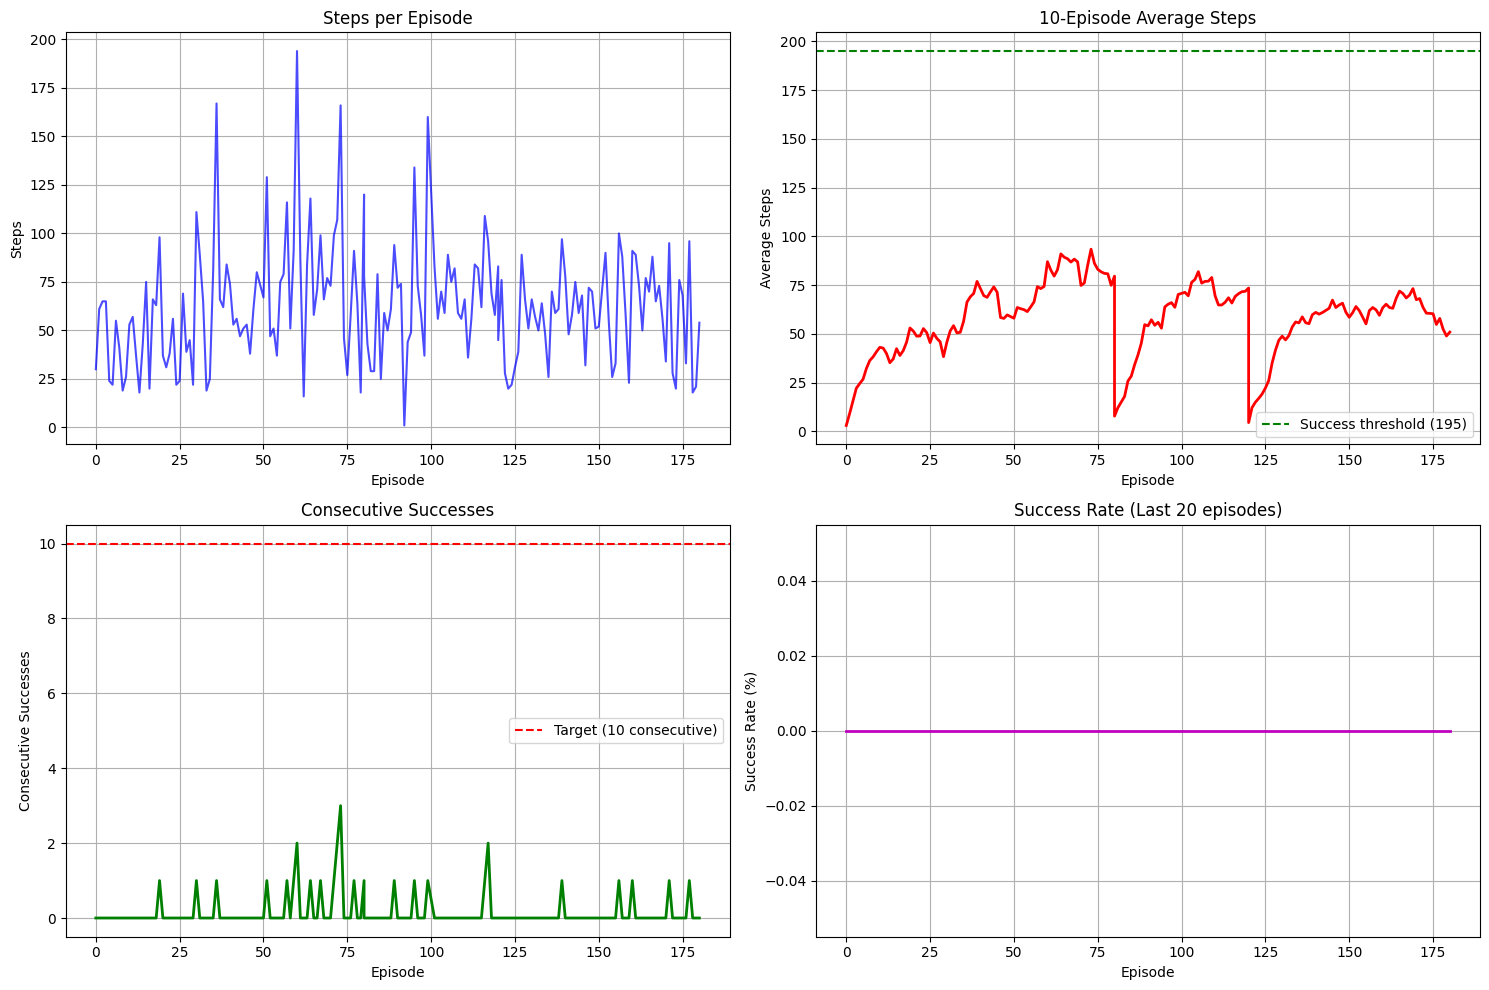


=== 学習統計 ===
総エピソード数: 181
総ステップ数: 11309
最新の10エピソード平均: 50.9 steps
最大連続成功回数: 3
最終成功率: 0.0%
学習改善度: 32.9 steps (初期10エピソード vs 最新10エピソード)


[SDK][ERROR][2025-10-15 09:55:58][base.py:247] - - [report-socket] recv error: [WinError 10054] 既存の接続はリモート ホストに強制的に切断されました。
[SDK][ERROR][2025-10-15 09:55:58][base.py:247] - - [report-socket] recv error: [WinError 10054] 既存の接続はリモート ホストに強制的に切断されました。
[SDK][ERROR][2025-10-15 09:55:58][base.py:247] - - [report-socket] recv error: [WinError 10054] 既存の接続はリモート ホストに強制的に切断されました。
[SDK][ERROR][2025-10-15 09:55:58][base.py:293] - - [main-socket] recv error: [WinError 10054] 既存の接続はリモート ホストに強制的に切断されました。
[SDK][ERROR][2025-10-15 09:55:58][base.py:293] - - [main-socket] recv error: [WinError 10054] 既存の接続はリモート ホストに強制的に切断されました。
[SDK][ERROR][2025-10-15 09:55:58][base.py:293] - - [main-socket] recv error: [WinError 10054] 既存の接続はリモート ホストに強制的に切断されました。


In [ ]:
import matplotlib.pyplot as plt

def plot_training_progress(brain):
    """学習進行状況をプロットする"""
    if not brain.training_history:
        print("学習履歴がありません")
        return
    
    # データの抽出
    episodes = [record['episode'] for record in brain.training_history]
    steps_per_episode = [record['steps'] for record in brain.training_history]
    avg_steps = [record['avg_steps'] for record in brain.training_history]
    complete_episodes = [record['complete_episodes'] for record in brain.training_history]
    
    # プロット作成
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. エピソードごとのステップ数
    axes[0, 0].plot(episodes, steps_per_episode, 'b-', alpha=0.7)
    axes[0, 0].set_title('Steps per Episode')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Steps')
    axes[0, 0].grid(True)
    
    # 2. 10エピソード平均ステップ数
    axes[0, 1].plot(episodes, avg_steps, 'r-', linewidth=2)
    axes[0, 1].axhline(y=195, color='g', linestyle='--', label='Success threshold (195)')
    axes[0, 1].set_title('10-Episode Average Steps')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Average Steps')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # 3. 連続成功回数
    axes[1, 0].plot(episodes, complete_episodes, 'g-', linewidth=2)
    axes[1, 0].axhline(y=10, color='r', linestyle='--', label='Target (10 consecutive)')
    axes[1, 0].set_title('Consecutive Successes')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Consecutive Successes')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # 4. 学習の進行（成功率の推移）
    success_rate = []
    window_size = 20
    for i in range(len(steps_per_episode)):
        start_idx = max(0, i - window_size + 1)
        recent_steps = steps_per_episode[start_idx:i+1]
        success_count = sum(1 for s in recent_steps if s >= 195)
        success_rate.append(success_count / len(recent_steps) * 100)
    
    axes[1, 1].plot(episodes, success_rate, 'm-', linewidth=2)
    axes[1, 1].set_title(f'Success Rate (Last {window_size} episodes)')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Success Rate (%)')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報の表示
    print("\n=== 学習統計 ===")
    print(f"総エピソード数: {len(episodes)}")
    print(f"総ステップ数: {brain.total_steps}")
    print(f"最新の10エピソード平均: {avg_steps[-1]:.1f} steps")
    print(f"最大連続成功回数: {max(complete_episodes)}")
    print(f"最終成功率: {success_rate[-1]:.1f}%")
    
    # 学習の改善度を計算
    if len(avg_steps) > 10:
        early_avg = np.mean(avg_steps[:10])
        recent_avg = np.mean(avg_steps[-10:])
        improvement = recent_avg - early_avg
        print(f"学習改善度: {improvement:.1f} steps (初期10エピソード vs 最新10エピソード)")

# 使用例
plot_training_progress(cartpole_env.agent.brain)

In [16]:
def analyze_q_values(agent, test_states):
    """Q値の分析"""
    agent.brain.main_q_network.eval()
    
    print("=== Q値分析 ===")
    with torch.no_grad():
        for i, state in enumerate(test_states):
            state_tensor = torch.from_numpy(state).type(torch.FloatTensor).unsqueeze(0)
            q_values = agent.brain.main_q_network(state_tensor)
            
            print(f"\n状態 {i+1}: [cart_pos: {state[0]:.3f}, cart_vel: {state[1]:.3f}, "
                  f"pole_angle: {state[2]:.3f}, pole_vel: {state[3]:.3f}]")
            print(f"Q値 - 左: {q_values[0][0]:.3f}, 右: {q_values[0][1]:.3f}")
            print(f"選択行動: {'左' if q_values[0][0] > q_values[0][1] else '右'}")

# 使用例（いくつかのテスト状態で確認）
test_states = [
    np.array([0.0, 0.0, 0.0, 0.0, 1.0]),      # 中央、静止、右に動いた
    np.array([0.1, 0.0, 0.14, 0.0, 1.0]),      # 右寄り、右傾き、右に動いた
    np.array([-0.1, 0.0, -0.14, 0.0, 1.0]),    # 左寄り、左傾き、右に動いた
]

analyze_q_values(cartpole_env.agent, test_states)

=== Q値分析 ===

状態 1: [cart_pos: 0.000, cart_vel: 0.000, pole_angle: 0.000, pole_vel: 0.000]
Q値 - 左: -0.197, 右: -0.187
選択行動: 右

状態 2: [cart_pos: 0.100, cart_vel: 0.000, pole_angle: 0.140, pole_vel: 0.000]
Q値 - 左: -0.198, 右: -0.207
選択行動: 左

状態 3: [cart_pos: -0.100, cart_vel: 0.000, pole_angle: -0.140, pole_vel: 0.000]
Q値 - 左: -0.217, 右: -0.203
選択行動: 右


=== メモリ分析開始 ===
メモリサイズ: 10000 件
検出されたエピソード数: 147
Episode 1: Steps=64, Total Reward=-1.0, Final Reward=-1.0
Episode 2: Steps=48, Total Reward=-1.0, Final Reward=-1.0
Episode 3: Steps=26, Total Reward=-1.0, Final Reward=-1.0
Episode 4: Steps=70, Total Reward=-1.0, Final Reward=-1.0
Episode 5: Steps=59, Total Reward=-1.0, Final Reward=-1.0


C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:121: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:121: UserWarning: Glyph 36554 (\N{CJK UNIFIED IDEOGRAPH-8ECA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:121: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:121: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:121: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\

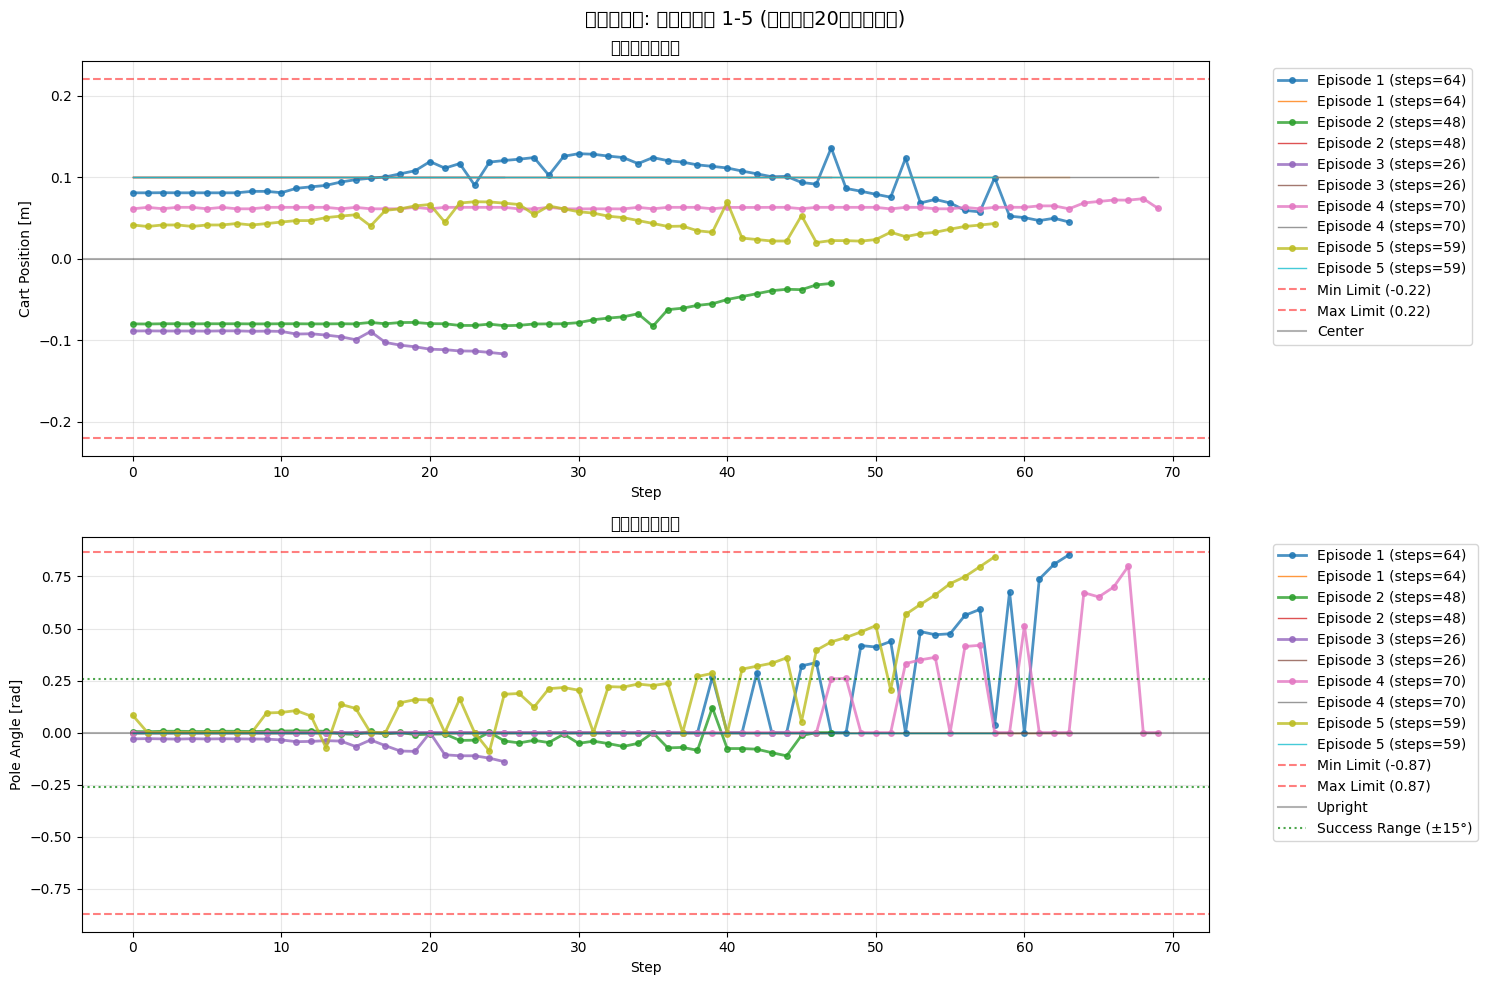

Episode 6: Steps=61, Total Reward=-1.0, Final Reward=-1.0
Episode 7: Steps=97, Total Reward=1.0, Final Reward=1.0
Episode 8: Steps=78, Total Reward=-1.0, Final Reward=-1.0
Episode 9: Steps=48, Total Reward=-1.0, Final Reward=-1.0
Episode 10: Steps=58, Total Reward=-1.0, Final Reward=-1.0


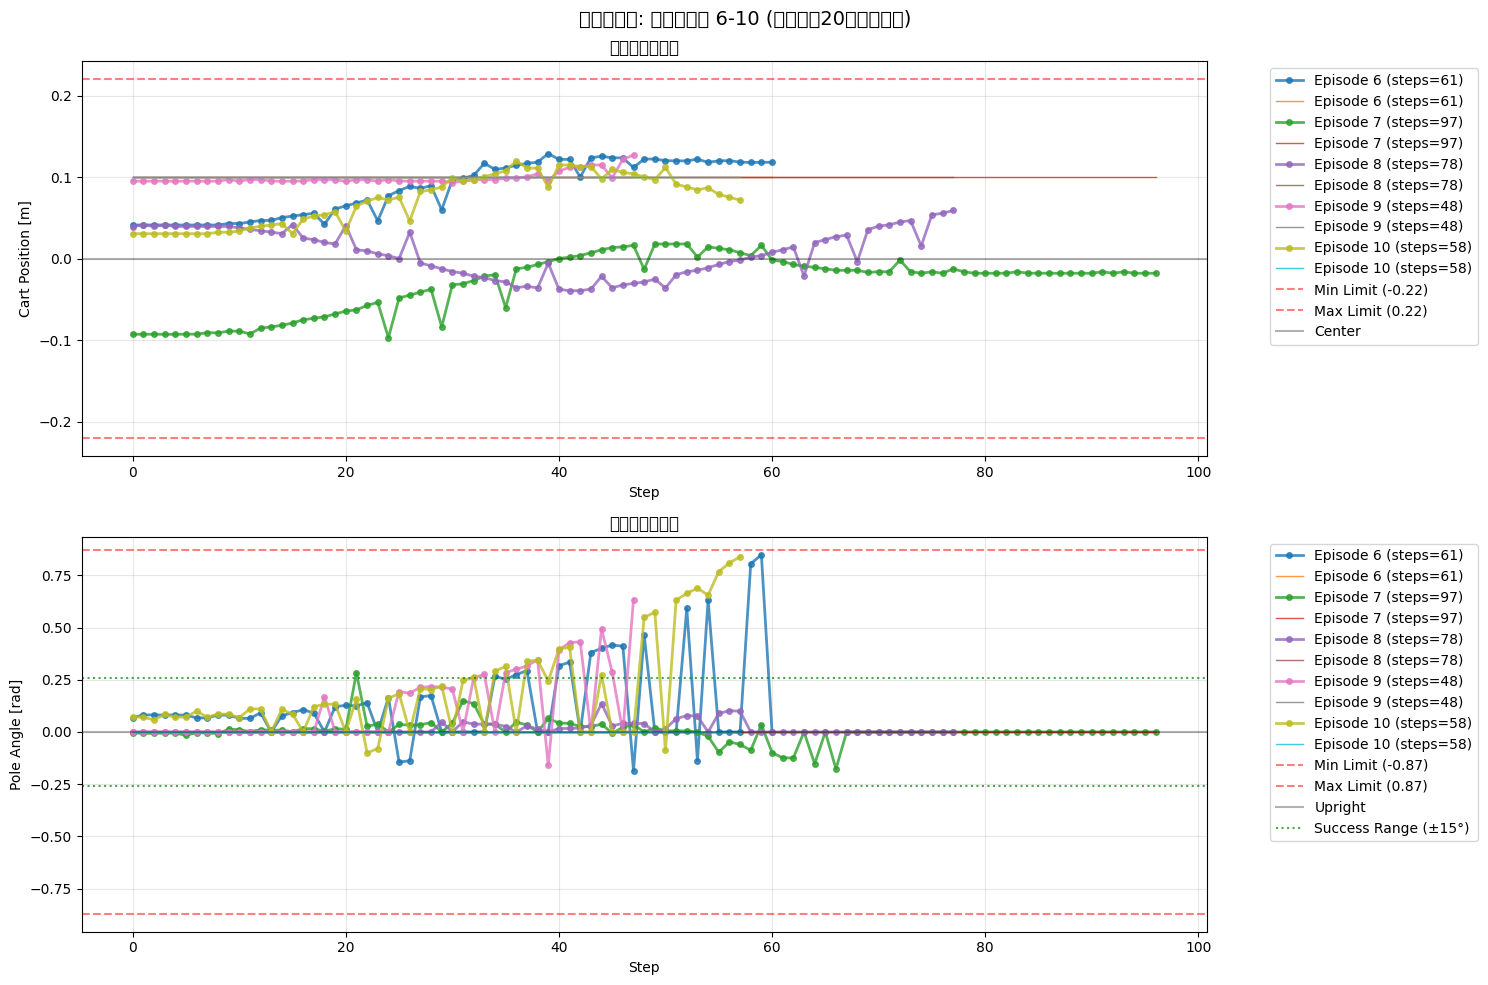

Episode 11: Steps=75, Total Reward=-1.0, Final Reward=-1.0
Episode 12: Steps=59, Total Reward=-1.0, Final Reward=-1.0
Episode 13: Steps=68, Total Reward=-1.0, Final Reward=-1.0
Episode 14: Steps=32, Total Reward=-1.0, Final Reward=-1.0
Episode 15: Steps=72, Total Reward=-1.0, Final Reward=-1.0


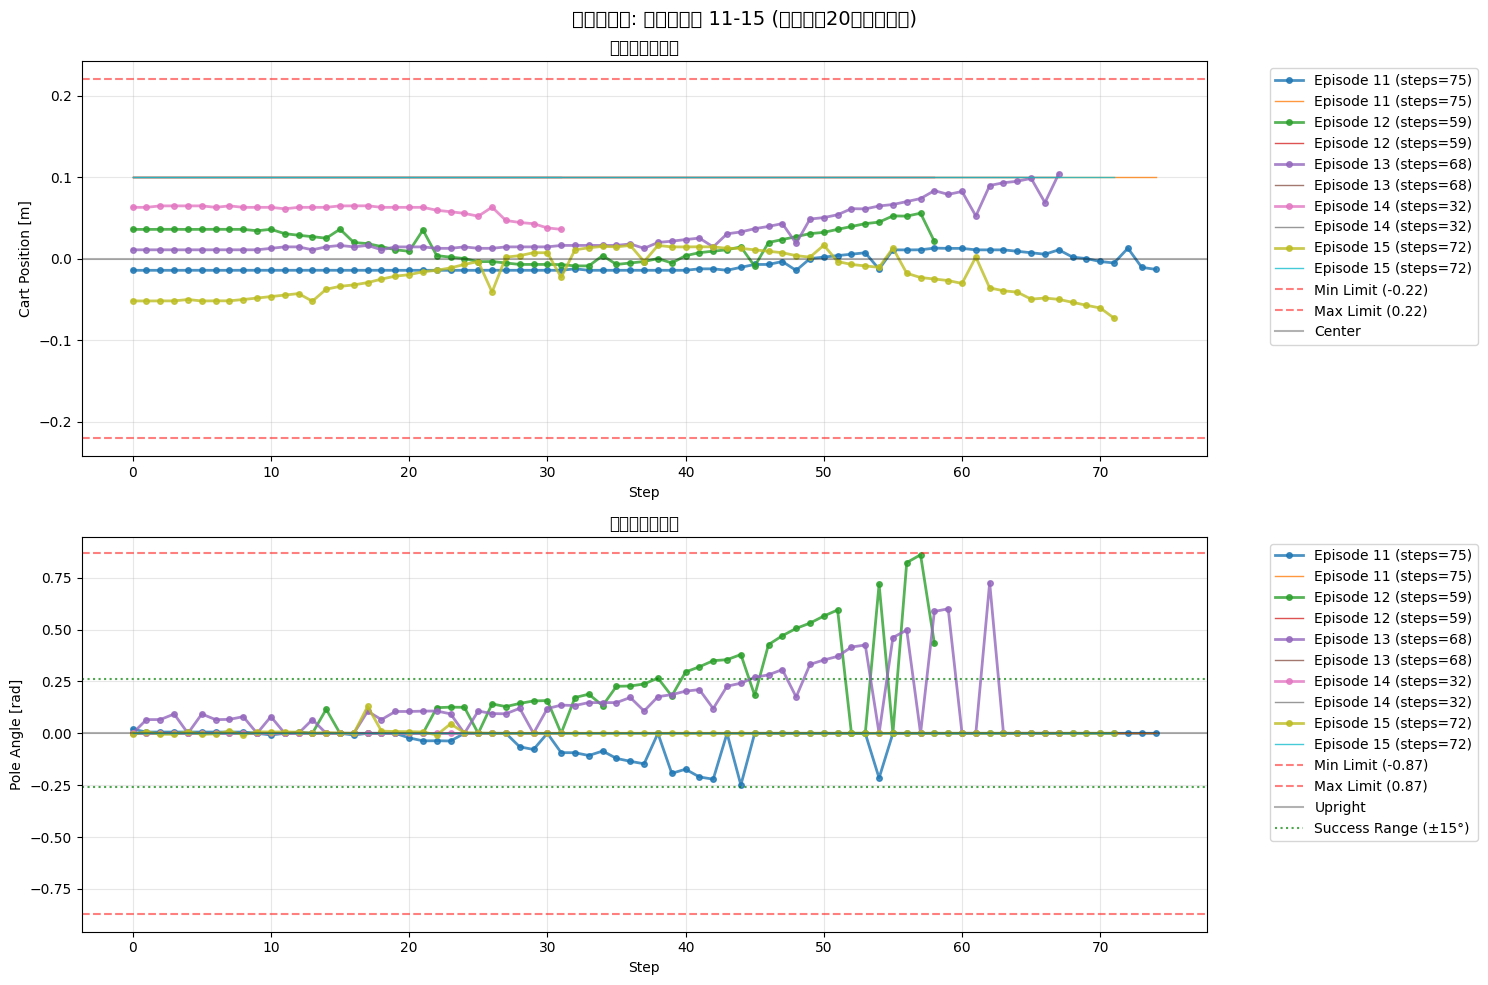

Episode 16: Steps=70, Total Reward=-1.0, Final Reward=-1.0
Episode 17: Steps=51, Total Reward=-1.0, Final Reward=-1.0
Episode 18: Steps=52, Total Reward=-1.0, Final Reward=-1.0
Episode 19: Steps=71, Total Reward=-1.0, Final Reward=-1.0
Episode 20: Steps=38, Total Reward=0.0, Final Reward=0.0


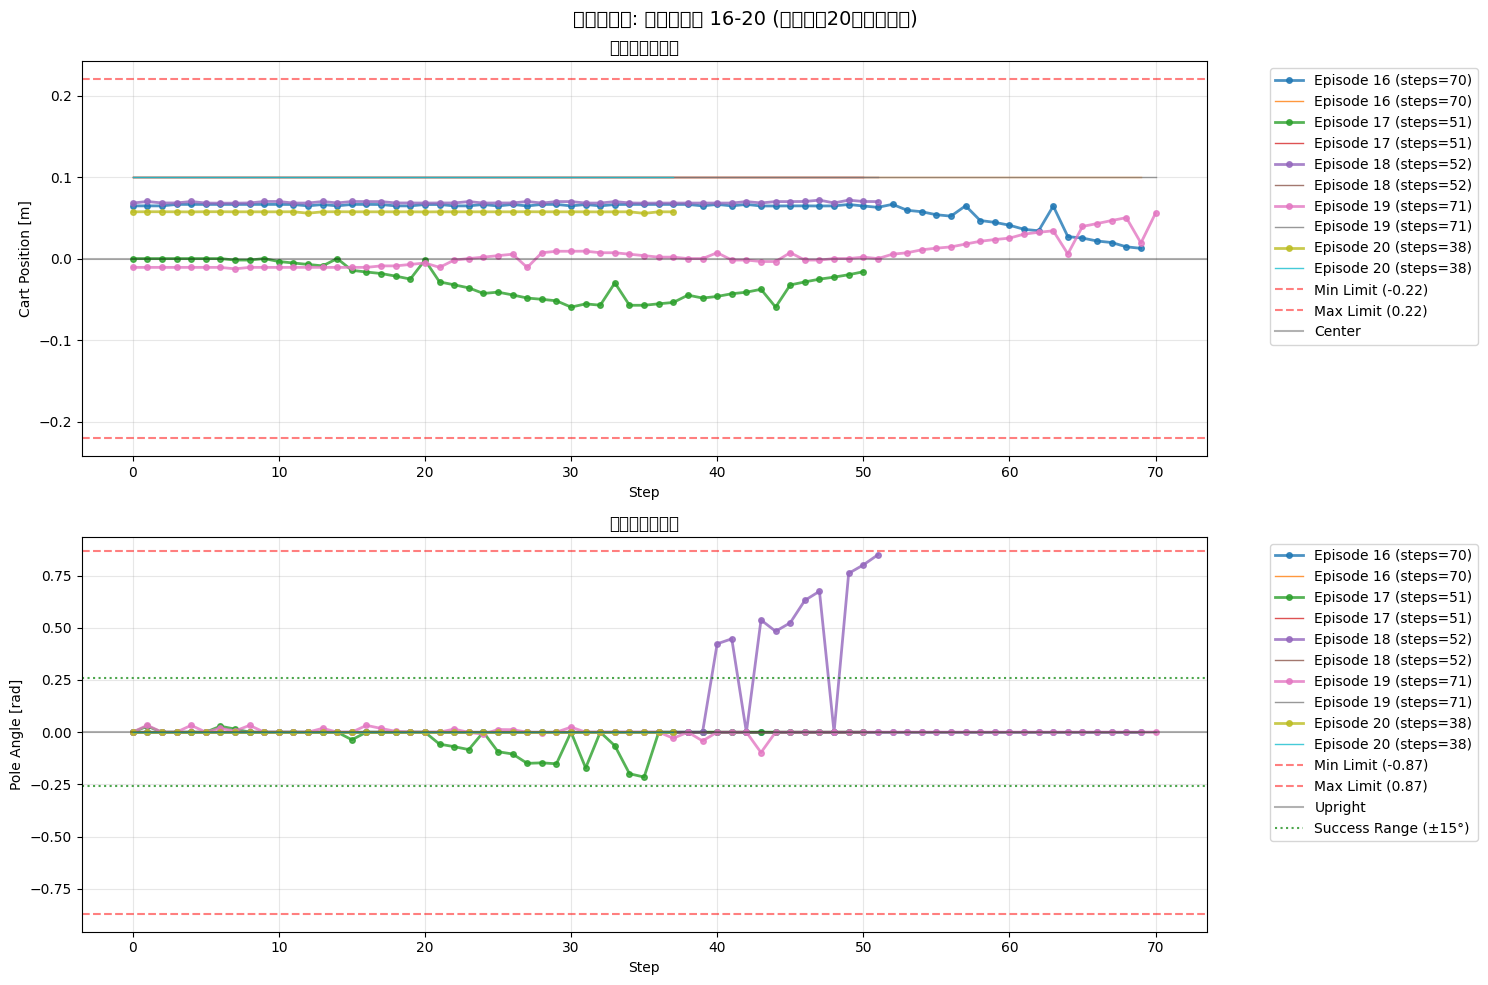


=== メモリ統計 ===
総サンプル数: 10000
台車位置 - 平均: 0.020, 標準偏差: 0.054
台車位置 - 最小: -0.117, 最大: 0.149
バー角度 - 平均: 0.062, 標準偏差: 0.157
バー角度 - 最小: -0.249, 最大: 1.056
報酬 - 正報酬: 22, 負報酬: 124, ゼロ: 9854
境界違反 - 台車位置: 0/10000 (0.0%)
境界違反 - バー角度: 1/10000 (0.0%)


C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:229: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:229: UserWarning: Glyph 36554 (\N{CJK UNIFIED IDEOGRAPH-8ECA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:229: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:229: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\1138324561.py:229: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KentaYonekura\AppData\Local\Temp\ipykernel_15256\

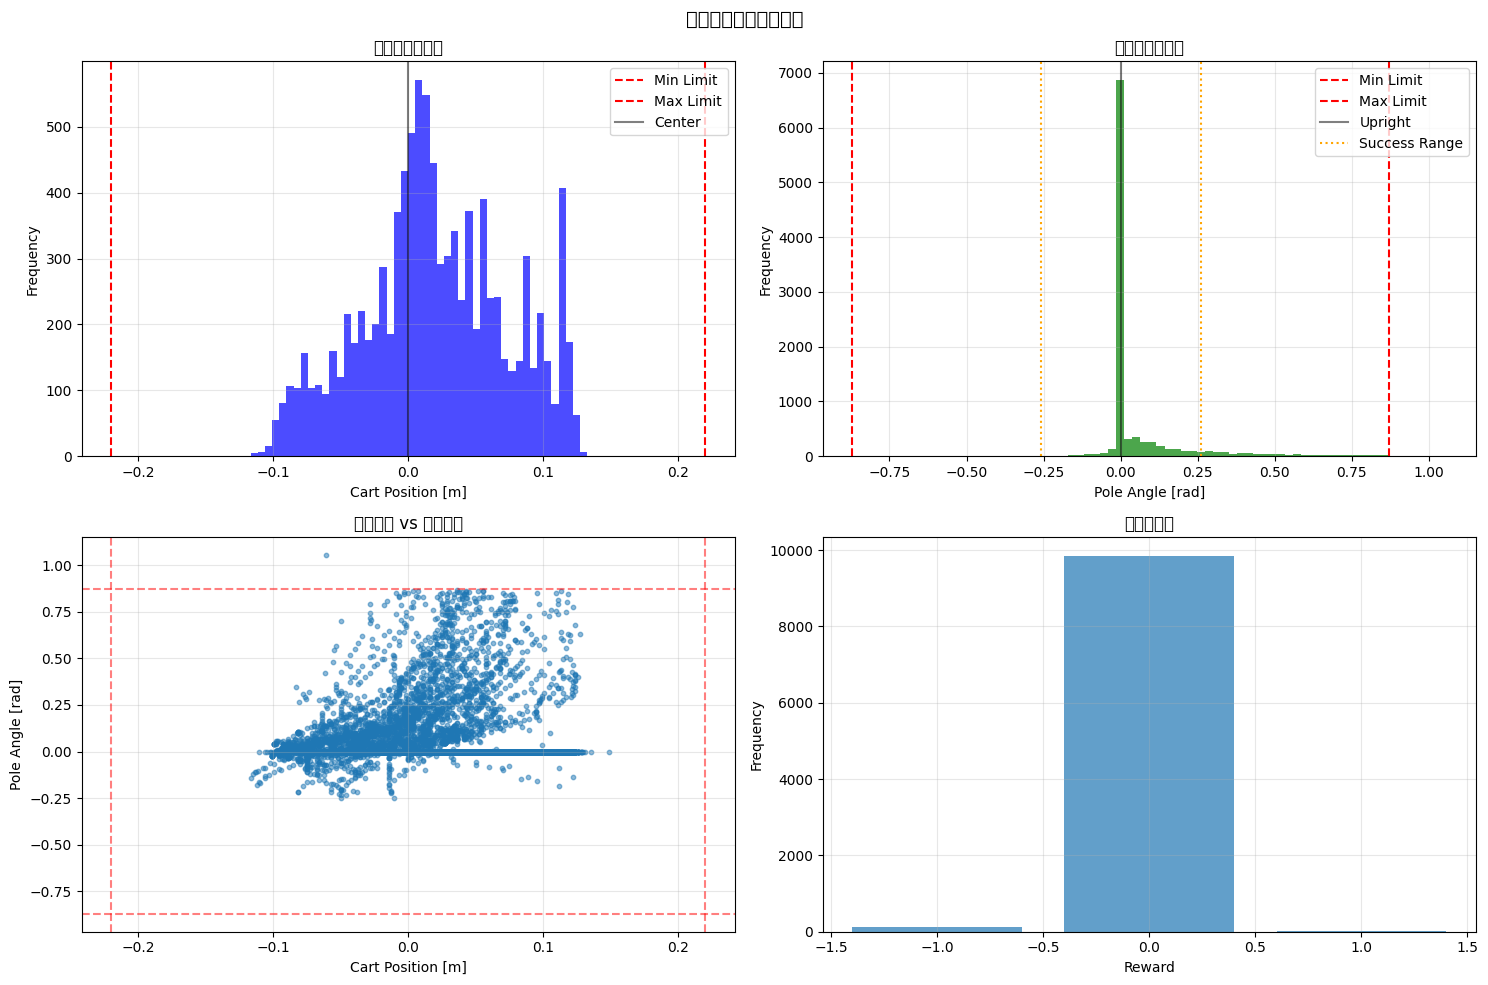

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_memory_episodes(brain, num_episodes_to_show=10, episodes_per_plot=10):
    """
    メモリに保存されたエピソードを分析し、台車位置とバーの角度を可視化
    """
    if len(brain.memory) == 0:
        print("メモリにデータがありません")
        return
    
    print(f"メモリサイズ: {len(brain.memory)} 件")
    
    # メモリからデータを取得
    memory_data = []
    for i in range(min(len(brain.memory), brain.memory.capacity)):
        if brain.memory.memory[i] is not None:
            transition = brain.memory.memory[i]
            memory_data.append(transition)
    
    if not memory_data:
        print("有効なメモリデータがありません")
        return
    
    # エピソードを分割（next_stateがNoneの場合がエピソードの終了）
    episodes = []
    current_episode = []
    
    for transition in memory_data:
        current_episode.append(transition)
        if transition.next_state is None:  # エピソード終了
            episodes.append(current_episode)
            current_episode = []
    
    # 最後のエピソードが未完了の場合も追加
    if current_episode:
        episodes.append(current_episode)
    
    print(f"検出されたエピソード数: {len(episodes)}")
    
    if len(episodes) == 0:
        print("完了したエピソードがありません")
        return
    
    # 最新のエピソードから指定数だけ表示
    episodes_to_plot = episodes[-num_episodes_to_show:] if len(episodes) >= num_episodes_to_show else episodes
    
    # episodes_per_plot個ずつグループ化してプロット
    num_plots = (len(episodes_to_plot) + episodes_per_plot - 1) // episodes_per_plot
    
    for plot_idx in range(num_plots):
        start_idx = plot_idx * episodes_per_plot
        end_idx = min(start_idx + episodes_per_plot, len(episodes_to_plot))
        current_episodes = episodes_to_plot[start_idx:end_idx]
        
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        fig.suptitle(f'メモリ分析: エピソード {start_idx+1}-{end_idx} (最新から{num_episodes_to_show}エピソード)', fontsize=14)
        
        # 各エピソードをプロット
        for ep_idx, episode in enumerate(current_episodes):
            episode_num = start_idx + ep_idx + 1
            
            # データを抽出
            cart_positions = []
            pole_angles = []
            valid_flag_cart = []
            valid_flag_pole = []
            rewards = []
            
            for transition in episode:
                state = transition.state.numpy().flatten()  # torch.Tensorをnumpy配列に変換
                cart_positions.append(state[0])  # cart_pos
                pole_angles.append(state[2])     # pole_angle
                valid_flag_cart.append(state[4]*0.1)
                valid_flag_pole.append(state[5]*0.1)
                rewards.append(transition.reward.item())  # reward
            
            steps = range(len(cart_positions))
            
            # 台車位置のプロット
            axes[0].plot(steps, cart_positions, 'o-', label=f'Episode {episode_num} (steps={len(cart_positions)})', 
                        linewidth=2, markersize=4, alpha=0.8)
            # 台車位置有効フラグ
            axes[0].plot(steps, valid_flag_cart, '-', label=f'Episode {episode_num} (steps={len(cart_positions)})', 
                        linewidth=1, alpha=0.8)
            
            # バー角度のプロット
            axes[1].plot(steps, pole_angles, 'o-', label=f'Episode {episode_num} (steps={len(pole_angles)})', 
                        linewidth=2, markersize=4, alpha=0.8)
            # バー角度有効フラグ
            axes[1].plot(steps, valid_flag_pole, '-', label=f'Episode {episode_num} (steps={len(cart_positions)})', 
                        linewidth=1, alpha=0.8)
            
            # エピソード情報を表示
            total_reward = sum(rewards)
            final_reward = rewards[-1] if rewards else 0
            print(f"Episode {episode_num}: Steps={len(cart_positions)}, Total Reward={total_reward:.1f}, Final Reward={final_reward:.1f}")
        
        # 台車位置のプロット設定
        axes[0].set_title('台車位置の推移')
        axes[0].set_xlabel('Step')
        axes[0].set_ylabel('Cart Position [m]')
        axes[0].axhline(y=MIN_CART_POS, color='r', linestyle='--', alpha=0.5, label=f'Min Limit ({MIN_CART_POS})')
        axes[0].axhline(y=MAX_CART_POS, color='r', linestyle='--', alpha=0.5, label=f'Max Limit ({MAX_CART_POS})')
        axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3, label='Center')
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[0].grid(True, alpha=0.3)
        
        # バー角度のプロット設定
        axes[1].set_title('バー角度の推移')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Pole Angle [rad]')
        axes[1].axhline(y=-MAX_POLE_ANGLE, color='r', linestyle='--', alpha=0.5, label=f'Min Limit ({-MAX_POLE_ANGLE:.2f})')
        axes[1].axhline(y=MAX_POLE_ANGLE, color='r', linestyle='--', alpha=0.5, label=f'Max Limit ({MAX_POLE_ANGLE:.2f})')
        axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3, label='Upright')
        axes[1].axhline(y=-0.26, color='g', linestyle=':', alpha=0.7, label='Success Range (±15°)')
        axes[1].axhline(y=0.26, color='g', linestyle=':', alpha=0.7)
        axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def analyze_memory_statistics(brain):
    """メモリの統計情報を分析"""
    if len(brain.memory) == 0:
        print("メモリにデータがありません")
        return
    
    # メモリからデータを取得
    cart_positions = []
    pole_angles = []
    cart_velocities = []
    pole_velocities = []
    rewards = []
    
    for i in range(min(len(brain.memory), brain.memory.capacity)):
        if brain.memory.memory[i] is not None:
            transition = brain.memory.memory[i]
            state = transition.state.numpy().flatten()
            
            cart_positions.append(state[0])
            cart_velocities.append(state[1])
            pole_angles.append(state[2])
            pole_velocities.append(state[3])
            rewards.append(transition.reward.item())
    
    print("\n=== メモリ統計 ===")
    print(f"総サンプル数: {len(cart_positions)}")
    print(f"台車位置 - 平均: {np.mean(cart_positions):.3f}, 標準偏差: {np.std(cart_positions):.3f}")
    print(f"台車位置 - 最小: {np.min(cart_positions):.3f}, 最大: {np.max(cart_positions):.3f}")
    print(f"バー角度 - 平均: {np.mean(pole_angles):.3f}, 標準偏差: {np.std(pole_angles):.3f}")
    print(f"バー角度 - 最小: {np.min(pole_angles):.3f}, 最大: {np.max(pole_angles):.3f}")
    print(f"報酬 - 正報酬: {sum(1 for r in rewards if r > 0)}, 負報酬: {sum(1 for r in rewards if r < 0)}, ゼロ: {sum(1 for r in rewards if r == 0)}")
    
    # 境界違反の分析
    cart_violations = sum(1 for pos in cart_positions if pos < MIN_CART_POS or pos > MAX_CART_POS)
    pole_violations = sum(1 for angle in pole_angles if angle < -MAX_POLE_ANGLE or angle > MAX_POLE_ANGLE)
    
    print(f"境界違反 - 台車位置: {cart_violations}/{len(cart_positions)} ({cart_violations/len(cart_positions)*100:.1f}%)")
    print(f"境界違反 - バー角度: {pole_violations}/{len(pole_angles)} ({pole_violations/len(pole_angles)*100:.1f}%)")

def plot_memory_distribution(brain):
    """メモリ内のデータ分布を可視化"""
    if len(brain.memory) == 0:
        print("メモリにデータがありません")
        return
    
    # メモリからデータを取得
    cart_positions = []
    pole_angles = []
    rewards = []
    
    for i in range(min(len(brain.memory), brain.memory.capacity)):
        if brain.memory.memory[i] is not None:
            transition = brain.memory.memory[i]
            state = transition.state.numpy().flatten()
            
            cart_positions.append(state[0])
            pole_angles.append(state[2])
            rewards.append(transition.reward.item())
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('メモリ内データの分布', fontsize=14)
    
    # 台車位置のヒストグラム
    axes[0, 0].hist(cart_positions, bins=50, alpha=0.7, color='blue')
    axes[0, 0].axvline(MIN_CART_POS, color='r', linestyle='--', label='Min Limit')
    axes[0, 0].axvline(MAX_CART_POS, color='r', linestyle='--', label='Max Limit')
    axes[0, 0].axvline(0, color='k', linestyle='-', alpha=0.5, label='Center')
    axes[0, 0].set_title('台車位置の分布')
    axes[0, 0].set_xlabel('Cart Position [m]')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # バー角度のヒストグラム
    axes[0, 1].hist(pole_angles, bins=50, alpha=0.7, color='green')
    axes[0, 1].axvline(-MAX_POLE_ANGLE, color='r', linestyle='--', label='Min Limit')
    axes[0, 1].axvline(MAX_POLE_ANGLE, color='r', linestyle='--', label='Max Limit')
    axes[0, 1].axvline(0, color='k', linestyle='-', alpha=0.5, label='Upright')
    axes[0, 1].axvline(-0.26, color='orange', linestyle=':', label='Success Range')
    axes[0, 1].axvline(0.26, color='orange', linestyle=':')
    axes[0, 1].set_title('バー角度の分布')
    axes[0, 1].set_xlabel('Pole Angle [rad]')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 台車位置 vs バー角度の散布図
    axes[1, 0].scatter(cart_positions, pole_angles, alpha=0.5, s=10)
    axes[1, 0].axvline(MIN_CART_POS, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].axvline(MAX_CART_POS, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].axhline(-MAX_POLE_ANGLE, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].axhline(MAX_POLE_ANGLE, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].set_title('台車位置 vs バー角度')
    axes[1, 0].set_xlabel('Cart Position [m]')
    axes[1, 0].set_ylabel('Pole Angle [rad]')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 報酬の分布
    reward_counts = {r: rewards.count(r) for r in set(rewards)}
    axes[1, 1].bar(reward_counts.keys(), reward_counts.values(), alpha=0.7)
    axes[1, 1].set_title('報酬の分布')
    axes[1, 1].set_xlabel('Reward')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 使用例
print("=== メモリ分析開始 ===")

# エピソード別の軌跡を分析（最新20エピソードを5エピソードずつ表示）
analyze_memory_episodes(cartpole_env.agent.brain, num_episodes_to_show=20, episodes_per_plot=5)

# 統計情報を表示
analyze_memory_statistics(cartpole_env.agent.brain)

# データ分布を可視化
plot_memory_distribution(cartpole_env.agent.brain)